# ASSIGNMENT 4: Linear and logistic regression

## Business understanding

The goal is to help price apartments in New Taipei City using facts about the properties. Appraising by hand is slow and two appraisers can end up with different prices. Instead, the models look at past sales data and use features like the age of the building, its location, the distance to the nearest MRT station and the shops nearby as their input, since all of these affect the price.

We have three objectives. First, estimate the price of unit area for a property. Second, tell whether a property is priced above or below the average. Third, find which features affect the price the most. The first is solved with linear regression, the second with logistic regression, and the third with the coefficients and permutation importance of both models.

We also set a goal for both models beforehand. The price estimate is good enough if it is off by less than 15% of the average price, and the classification is good enough if it puts at least three out of four properties in the right class.

## Data understanding

Pandas and MatplotLib libraries are imported to handle the dataset and create visualizations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

The assignment uses the Real Estate Valuation dataset by I-Cheng Yeh, available at the UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set). The data is collected from New Taipei City, Taiwan. 

The dataset is fetched from the source as `real_estate_valuation` and split into two data frames representing features `X` and targets `y`. 

In [2]:
from ucimlrepo import fetch_ucirepo 
  
real_estate_valuation = fetch_ucirepo(id=477) 
  
X = real_estate_valuation.data.features 
y = real_estate_valuation.data.targets

The dataset contains six features and one target variable describing the real estate characteristics and house prices:

In [3]:
real_estate_valuation.variables

,name,role,type,demographic,description,units,missing_values
0,No,ID,Integer,None,NaN,NaN,no
1,X1 transaction date,Feature,Continuous,None,"for example, 2013.250=2013 March, 2013.500=201...",NaN,no
2,X2 house age,Feature,Continuous,None,NaN,year,no
3,X3 distance to the nearest MRT station,Feature,Continuous,None,NaN,meter,no
4,X4 number of convenience stores,Feature,Integer,None,number of convenience stores in the living cir...,integer,no
5,X5 latitude,Feature,Continuous,None,"geographic coordinate, latitude",degree,no
6,X6 longitude,Feature,Continuous,None,"geographic coordinate, longitude",degree,no
7,Y house price of unit area,Target,Continuous,None,"10000 New Taiwan Dollar/Ping, where Ping is a ...",10000 New Taiwan Dollar/Ping,no


The `X4 number of convenience stores` is stored as an integer, while other values are stored as continuous types.

The variable `X1 transaction date` is calculated using the formula: `year + number of the month / 12`. (2013 March = 2013 + 3/12 = 2013.250).
The target variable `Y house price of unit area` is measured as `10 000 New Taiwan Dollars / Ping`, where Ping is a local unit, `1 Ping = 3.3 square meters`.

The data contains zero missing values.

In [4]:
X

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245
...,...,...,...,...,...,...
409,2013.000,13.7,4082.01500,0,24.94155,121.50381
410,2012.667,5.6,90.45606,9,24.97433,121.54310
411,2013.250,18.8,390.96960,7,24.97923,121.53986
412,2013.000,8.1,104.81010,5,24.96674,121.54067


The `X` dataframe contains 414 observations and 6 features.

In [5]:
y

,Y house price of unit area
0,37.9
1,42.2
2,47.3
3,54.8
4,43.1
...,...
409,15.4
410,50.0
411,40.6
412,52.5


The `y` contains the corresponding target values, representing house prices measured in 10 000 New Taiwan Dollars per Ping

## Data preperation

First, convert the `y` dataframe into a series.

In [6]:
y = y['Y house price of unit area']

Convert the X values to floats and print the five first rows.

In [7]:
for col in X.columns.values:
    if X[col].dtype != 'float64':
        X[col] = X[col].astype(dtype='float64')

X.head(5)

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10.0,24.98298,121.54024
1,2012.917,19.5,306.59470,9.0,24.98034,121.53951
2,2013.583,13.3,561.98450,5.0,24.98746,121.54391
3,2013.500,13.3,561.98450,5.0,24.98746,121.54391
4,2012.833,5.0,390.56840,5.0,24.97937,121.54245


At this point, the data frames will be split into the test and training sets using the `train_test_split` method provided by `sklearn`. 25% of the data will be left out for validation. 

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123)

After splitting the data, both sets will be standardized using `StandardScaler` provided by `sklearn`. The first five rows are printed as an example of the transformed values.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

X_train.head(5)

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,0.945014,0.008392,-0.067556,-1.392631,-0.524868,1.017443
1,-0.246786,-0.468570,0.219898,-1.049182,-1.415896,0.970115
2,1.241180,-1.153661,0.840932,-0.362284,-0.529724,-1.336628
3,0.052948,-0.095672,0.951876,-0.362284,-0.864770,-1.288004
4,-0.839118,-1.327102,0.295361,-1.049182,-1.483876,1.007718


The provided data does not contain any missing values nor outliers. Therefore, the data preperation doesn't include clean up. 

## Modeling

Two different regression models will be created in the modeling phase. The models do slightly different things meaning that they are not meant to be compared on their performance. The Linear Regression model will predict the house price of unit area for a house based on its feature values while the Logistic Regression model will predict whether the house price of unit area for a house is below or above the average based on the provided information. The models will be individually validated and analysed.

### Linear regression model (Riikka)

The Linear Regression model is built with the `LinearRegression` class that `Scikit-learn` library provides. Since split validation is used as the validation method, the model is trained with training set, `X_train` containing the features and `y_train` containing the target values, using the models `fit` method.

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 1.38,-3.12,-6.02, 3.12, 2.77,-0.47]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['X1 transaction date','X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores','X5 latitude','X6 longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,38.06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


From the trained model the intercept ($\beta_0$) and coefficient values ($\beta_1$, $\beta_2$, $\beta_3$, $\beta_4$, $\beta_5$, $\beta_6$) for the linear regression equation can be inspected. These values were determined to provide the best fit with the training data meaning they minimize the mean squared error or `MSE` value compared to other combinations.

In [11]:
b0 = model.intercept_ # note the underscore!
b1 = model.coef_ # returns a list containing a single element

print("Intercept: %.2f" % b0)

for b, name in zip(b1, model.feature_names_in_):
    print(name + ", Coefficient: %.4f" % b)

Intercept: 38.06
X1 transaction date, Coefficient: 1.3819
X2 house age, Coefficient: -3.1150
X3 distance to the nearest MRT station, Coefficient: -6.0160
X4 number of convenience stores, Coefficient: 3.1183
X5 latitude, Coefficient: 2.7696
X6 longitude, Coefficient: -0.4677


The coefficient values provide information on how the different features affect the prediction. Negative values decrease the prediction while positive values increase the prediction. From the estimated values we can see that the X3 feature `distance to the nearest MRT station` and the X4 `number of convenience stores` feature have the biggest impact on the prediction, but they have an opposite effect, X3 decreases and X4 increases prediction or the `house price of unit area`. The X6 `longitude` and X1 `transaction date` features seem to impact the least to the `house price of unit area`.

This phase also highlights the importance of standardization of the data. Without standardization the feature values would all be on different scales (e.g. X4 distance to the nearest MRT station vs. X3 number of convenience stores) and the model would conclude that the feature which values are on a higher scale has a bigger impact on the prediction only because the value is larger. With standardization all the features are on the same scale and the model can estimate the importance of the features properly.

Feature importance can be also estimated with permutation importance. `Scikit-learn` provides a function, `permutation_importance` that estimates the feature importances. The `n_repeats` parameter specifies how many times the permutation process is repeated. The permutation importance was estimated on the train dataset. The following graph visualizes the permutation importance.

/var/folders/q9/3lq265vn6s5gcmgb5vd5lk5h0000gn/T/ipykernel_33785/3972732130.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=X.columns[sorted_idx])


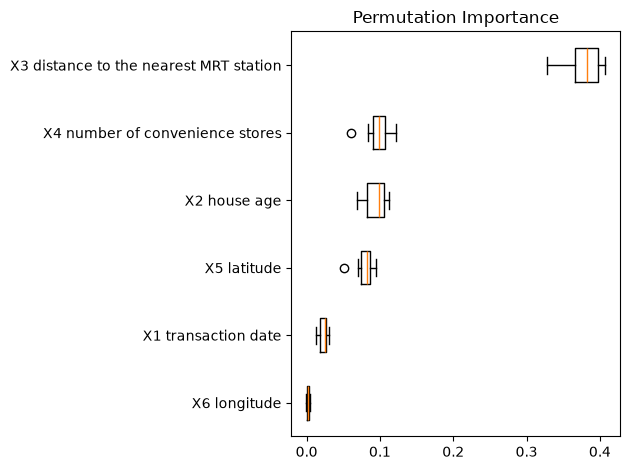

In [12]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_train, y_train, n_repeats=10, random_state=0, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots()
ax.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=X.columns[sorted_idx])
ax.set_title("Permutation Importance")
fig.tight_layout()
plt.show()

Once again we can see that the X3 `distance to the nearest MRT station` and X4 `number of convenience stores` features have the biggest impact and the X6 `longitude` and X1 `transaction date` features the smallest impact on the prediction.

The following graphs visualize the linear trendlines for each feature on the training data. We also noticed that without standardization the graphs were illegible. The intercept value was really high and the coefficient values were all on different scales. These made the datapoints in the graphs concentrate on the top and the trendline was on the bottom. There was no way to analyse the graphs.

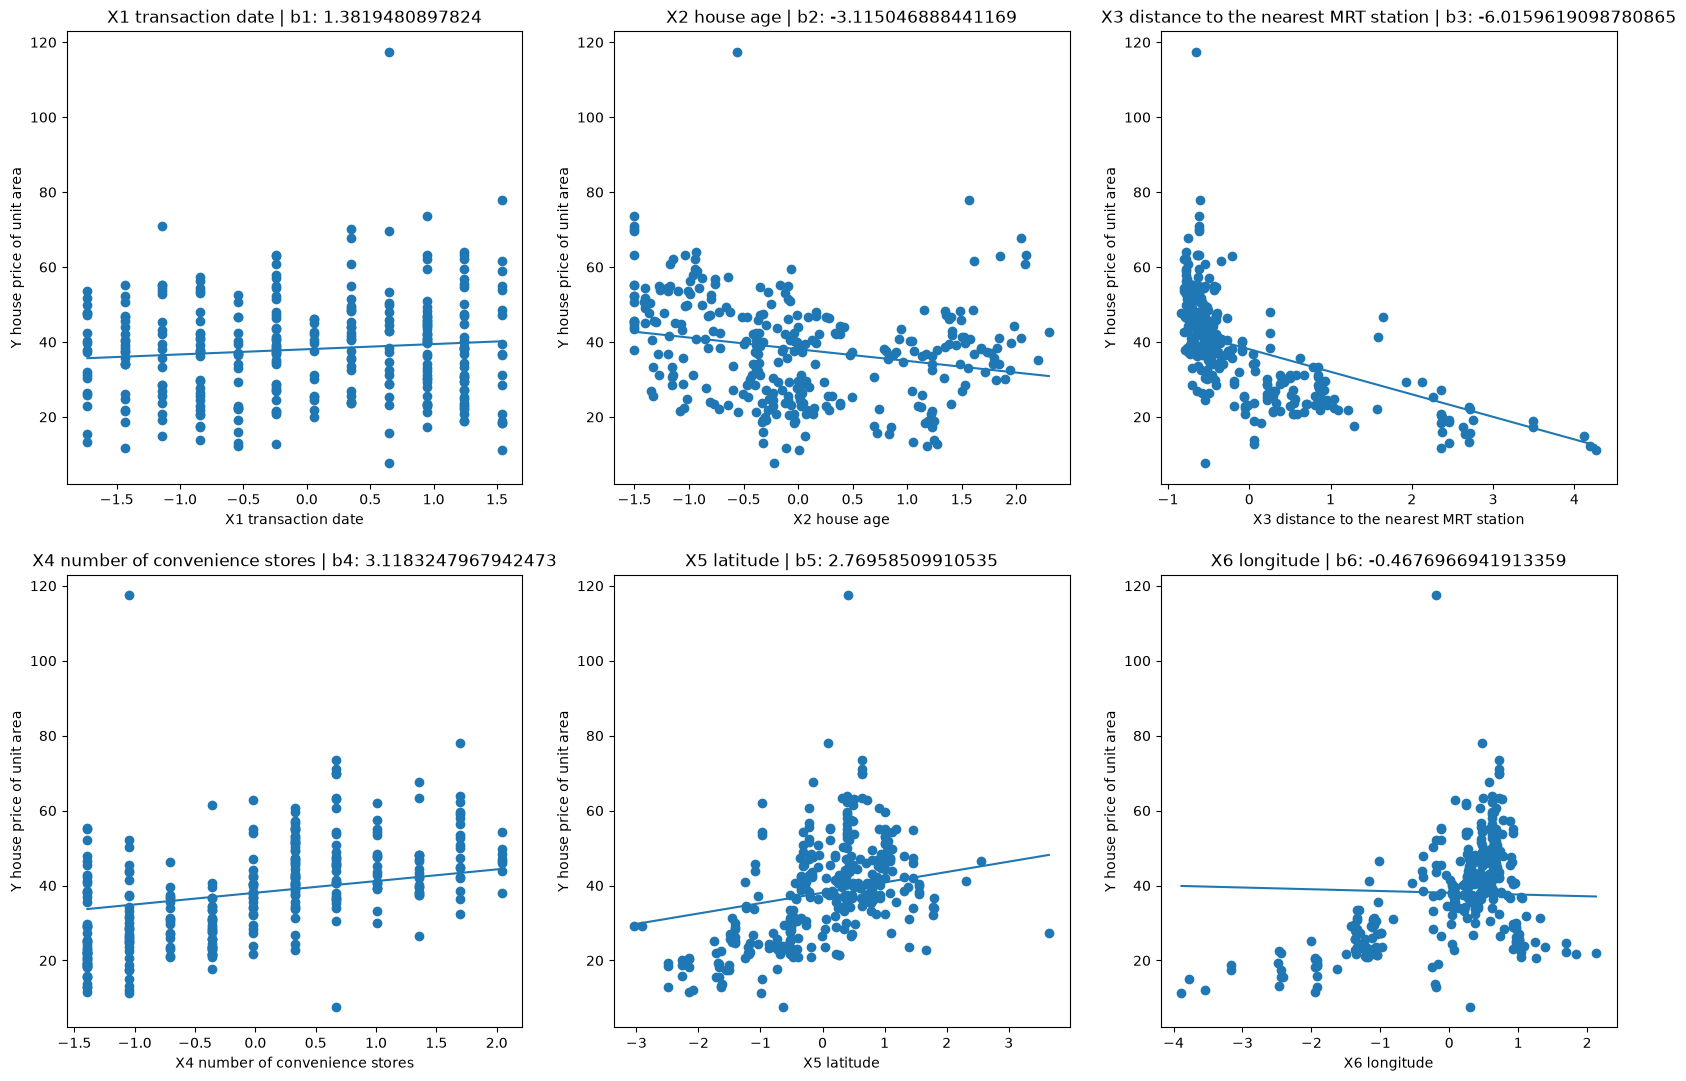

In [13]:
import numpy as np

count = 1
plt.figure(figsize=(20, 20))
for col, b in zip(X_train.columns, b1):
    plt.subplot(3, 3, count)
    xs = np.linspace(X_train[col].min(), X_train[col].max())
    ys = b0 + b * xs
    plt.plot(xs, ys)
    plt.scatter(X_train[col], y_train)
    plt.xlabel(col)
    plt.ylabel('Y house price of unit area')
    plt.title("" + str(col) + " | b" + str(count) + ": " + str(b))
    count+=1
    
plt.show()

All the trendlines are either linearly growing or linearly decaying. Linearly growing trendlines indicate that the house price of unit area will increase with higher feature values and linearly decaying trendlines indicate that the house price of unit area will decrease with higher feature values. We can see that higher values in X4 `number of convenience stores` and X5 `latitude` features seem to indicated higher house price of unit area while higher values in X2 `house age` and X3 `distance to the nearest MRT station` features seem to indicate lower house price of unit area.

The model is validated and tested using the test set, `X_test` containing the features and `y_test` containing the target values. The `predict` method of the model predicts the value for the sample based on the features.

The validation metric used to evaluate the performance of the linear regression model is mean absolute error or `MAE`. The MAE score measures how much the predicted values differ from the actual values on average. `Scikit-learn` library provides the `mean_absolute_error` function for calculating the MEA score. It takes the actual target values and the predicted values as parameters.

In [14]:
from sklearn.metrics import mean_absolute_error

preds = model.predict(X_test)
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, preds))

Mean absolute error: 5.14


The MEA score for the model is 5.14. This means that the predicted house price of unit area values differ from the actual values by 5.14 (10000 Taiwan Dollars / Ping) or by 54000 Taiwan Dollars per ping. 

Residuals can also be used to evaluate the linear regression models suitability to make predictions from the provided data. The residuals are the difference between the predicted values and true values. The grap below visualizes the residuals.

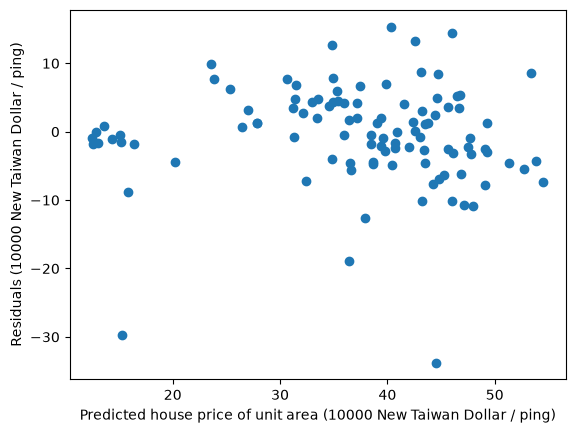

In [15]:
plt.scatter(preds, preds - y_test)
plt.xlabel('Predicted house price of unit area (10000 New Taiwan Dollar / ping)')
plt.ylabel('Residuals (10000 New Taiwan Dollar / ping)')
plt.show()

The graph indicates that linear regression is suitable for this dataset though not a perfect fit. Most of the residuals are distributed around the horizontal zero line and there is no noticeable trend in the variance but there are some outliers so variance cannot be considered to be a constant either. It is worth noting that the original dataset was fairly small and contained some samples that noticeably differed from the majority of the data, making it hard for the trained model to make correct predictions for these samples if they were in the test set resulting in the large residuals for these samples during validation.

### Logistic regression model (Nur)

The logistic regression model is used to classify the house price into two categories. The original continous house price is converted into a binary variable based on the average house price in the training data. This avoids using information from the test set when definition the classification threshold.

In [16]:
import numpy as np

mean = y_train.mean()
print(mean)

y_train_b = (y_train > mean).astype(int)
y_test_b = (y_test > mean).astype(int)

38.0641935483871


The average house price of unit area in the training set is approximately 38.06 (10 000 New Taiwan Dollars/Ping). This value is used as the classification threshold. Properties with a price above this value are labeled as 1 (above average), while properties with a price at or below this value are labeled as 0 (below or equal to average).

The LogisticRegression class provided by Scikit learn is used to build the model. The logistic regression model is trained using the standarized training features and the binary target.

In [20]:
from sklearn.linear_model import LogisticRegression

reg_model = LogisticRegression(solver='lbfgs')
reg_model.fit(X_train, y_train_b)

b0 = reg_model.intercept_[0] # note the underscore!
b1 = reg_model.coef_[0] # returns a list containing a single element

print("Intercept: %.4f" % b0)
for b, name in zip(b1, reg_model.feature_names_in_):
    print(name + ", Coefficient: %.4f" % b)

Intercept: -0.7741
X1 transaction date, Coefficient: 0.3425
X2 house age, Coefficient: -0.7294
X3 distance to the nearest MRT station, Coefficient: -2.4240
X4 number of convenience stores, Coefficient: 0.6232
X5 latitude, Coefficient: 1.0745
X6 longitude, Coefficient: 0.2678


The coeffiicients show the direction of the relationship between the standardized features and the predicted binary class. A positive coefficient means that an increase in that feature increases the probability of an above-average price, while a negative coefficient decreases it.

From these values, we can see that the X3 feature, distance to the nearest MRT station, has the largest negative coefficient. X2 house age is also has negative coefficient, meaning older properties tend to be priced below average. X5 latitude and X4 number of convenience stores features have the largest positive coefficients, meaning the higher latitude and more nearby convinience stores raise the probability of an above-average price. X1 transaction date and X6 longitude have the smallest coefficients in magnitude, indicating a comparatively minor influence on whether a property is priced above or below average.

The trained logistic regression model is validated using the test data. The `predict` method is used to predict whether each test sample belongs to the below-average or above-average price class. The predictictions are then evaluated using accuracy and a confusion matrix. `Matplotlib` is used to visualize the confusion matrix.

Accuracy: 0.81
Confusion Matrix:
 [[38 10]
 [10 46]]


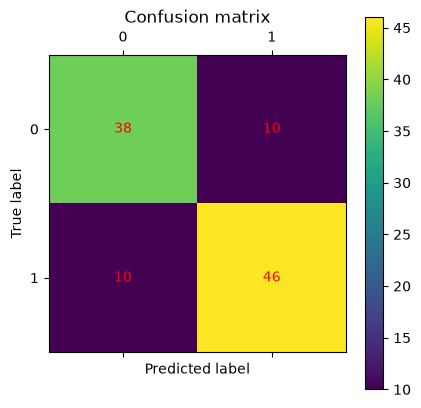

In [18]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

preds = reg_model.predict(X_test)

cm = confusion_matrix(y_test_b, preds)
accuracy = accuracy_score(y_test_b, preds)

print("Accuracy: %0.2f" % accuracy)
print("Confusion Matrix:\n", cm)

# visualize confusion matrix
plt.matshow(cm)
plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')

# include counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.show()

The model predicts the outcome quite well, with an accuracy of `0.81`. It correctly classifies about 81% of properties as above or below average price. The confution matrix shows 38 samples were correctly classified as below average, and 46 samples were correctly clasiified as above average. There were 10 incorrect predictions in each class.

Permutation importance is used to estimate the relative importance of the input features. `Scikit-learn` provides a mechanism called `permutation importance`, which repeatedly shuffles the values of each feature and observes how this affects model's accuracy. A larger decrease in accuracy indicates that the feature is more important for the model.

/var/folders/q9/3lq265vn6s5gcmgb5vd5lk5h0000gn/T/ipykernel_33785/2495848505.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=X.columns[sorted_idx])


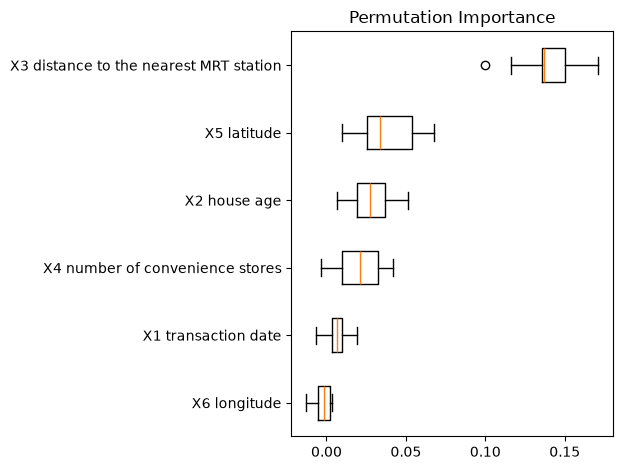

In [19]:
from sklearn.inspection import permutation_importance

result = permutation_importance(reg_model, X_train, y_train_b, n_repeats=10, scoring="accuracy", random_state=0, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots()
ax.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=X.columns[sorted_idx])
ax.set_title("Permutation Importance")
fig.tight_layout()
plt.show()

According to the permutation importance results, X3 distance to the nearest MRT staion is the most important feature for the logistic regression model. X6 longitude has the smallest importance. This means that suffling X3 has the largest effect on the model's classification accuracy, while suffling X6 has the smallest effect among the input features.

## Evaluation

In this chapter both models are checked against the goals we set in the business understanding chapter. The models answer different questions, so they are looked at separately and their results are not compared with each other.

### Linear regression model

The mean absolute error on the test set was 5.14, so the estimate is off by about 51 400 New Taiwan Dollars per ping on average. The average price in the training data was 38.06, so the error is about 14% (= 5.14/38.06) of the average price. This is just inside the goal we set (15%), so the model is accurate enough for a first estimate, but not for deciding the final price.

The coefficients show that `X3 distance to the nearest MRT station` (-6.02) has the most effect on property prices. Next are `X2 house age` (-3.12) and `X4 number of convenience stores` (+3.12), which are about equally important but pull the price in opposite directions. `X5 latitude` (+2.77) has less effect, and `X1 transaction date` (+1.38) and `X6 longitude` (-0.47) matter the least. Permutation importance gave the same order.

The residuals are mostly around zero with no clear trend, so linear regression suits this data. Still, a few samples have very large residuals, so the model can be wrong for unusual properties.

### Logistic regression model

The limit between the two classes is the average price of the training data (38.06). It was calculated from the training data only and then applied to the test set as well. If the limit had been calculated from the whole dataset, the model would already have used information about the test properties while it was trained, and the test result would look better than it really is.

The model got 81% of the test properties right, so it passes the goal we set of three out of four. It placed 38 below-average and 46 above-average properties in the correct classes and made 10 mistakes in both directions, so it does not lean strongly towards either side.

Permutation importance is in line with the linear model: `X3 distance to the nearest MRT station` is the most important feature and `X6 longitude` the least important. Two different models agreeing makes the result more believable.

## Deployment

With modification and additional data, these models could be of use for a few use cases: a real estate agent could get a price suggestion before meeting a propery seller, the agency could check whether an asking price is clearly above or below the market average, and a buyer could see which apartments are cheap for their features. Property market prices change over time, so the models need retraining with newer data to stay useful.